# XGBoost Return Prediction Strategy

This notebook explores a **machine learning approach for predicting asset returns** using the **XGBoost regression model**.

The objective is to determine whether engineered features extracted from financial time series can help predict **future log returns** and generate a **systematic trading strategy**.

The workflow follows a typical quantitative research pipeline:

1. Data collection
2. Feature engineering
3. Model training
4. Prediction
5. Strategy backtesting
6. Performance comparison with a Buy & Hold benchmark

## Libraries
We import the main Python libraries used for data processing, visualization, and machine learning.

In [627]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from binance.client import Client
import matplotlib.pyplot as plt
import mplfinance as mpf
import xgboost as xgb
import seaborn as sns
import pandas as pd
import numpy as np
import ta

## Utility Functions

This section defines helper functions used later in the notebook.

For example, we compute the **annualization factor** used to convert Sharpe ratios depending on the data frequency.

In [628]:
def get_sharpe_annualization_factor(interval_minutes):
    minutes_per_year = 365 * 24 * 60
    periods_per_year = minutes_per_year / interval_minutes
    return np.sqrt(periods_per_year)

In [629]:
ticker = "BTCUSDT"

hist_data = 7 * 4 * 6 # Six month 

interval = 60 # In minutes

forecast_horizon = 1 

annualize_rate = get_sharpe_annualization_factor(interval) # Sharpe annualize rate 

## Data Collection

Historical market data is retrieved using the Binance API.

Parameters:
- **Asset:** BTCUSDT
- **Time interval:** 1 hour
- **History:** approximately six months of data

The dataset includes standard OHLCV market data:
- Open
- High
- Low
- Close
- Volume

In [630]:
client = Client("", "")
dict_data = client.get_historical_klines("BTCUSDT", Client.KLINE_INTERVAL_1HOUR, "1 Jan, 2024")

df = pd.DataFrame(dict_data)

df = df.iloc[:, :6]

df.columns = ['Time', 'Open', 'High', 'Low', 'Close', 'Volume']

df['Time'] = pd.to_datetime(df['Time'], unit='ms')

df.set_index('Time', inplace=True)

df = df.apply(pd.to_numeric)

## Price Visualization

Before building the model, we visualize the asset price using a candlestick chart to better understand the market behavior over the sample period.

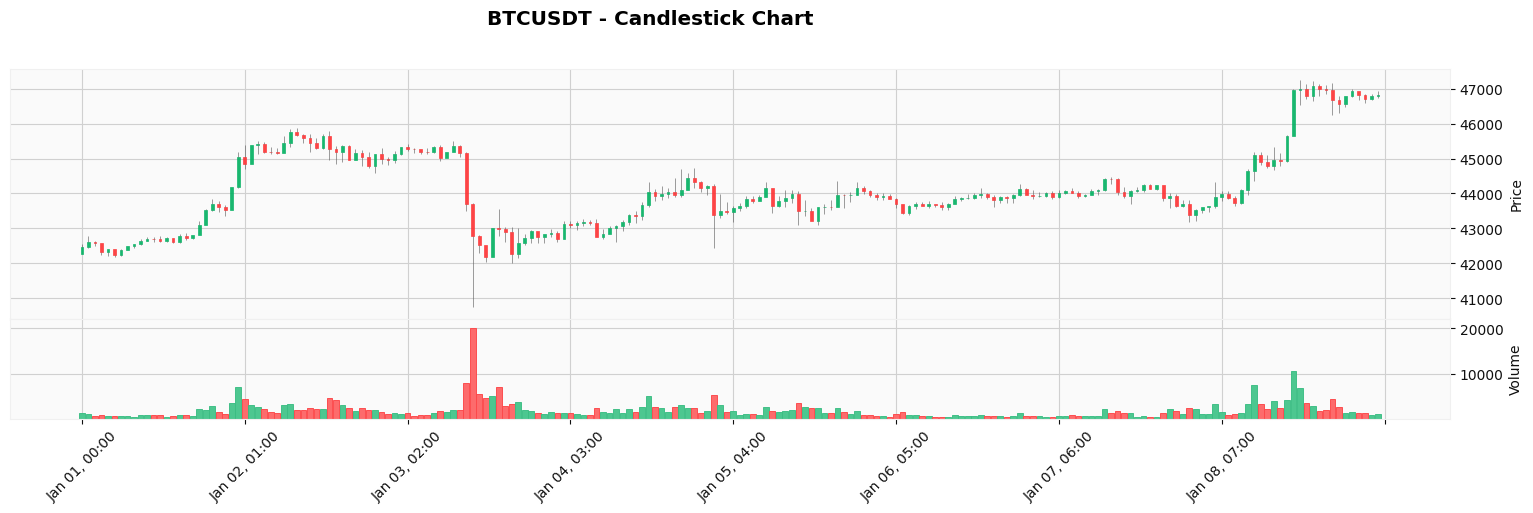

In [631]:
mpf.plot(
    df.head(200),
    type="candle",
    style="yahoo",
    figsize=(20, 5),
    volume=True,
    title=f"{ticker} - Candlestick Chart"
)

## Feature Engineering

Financial time series are transformed into predictive variables.

Examples of engineered features include:

- price changes
- volatility measures
- lagged returns
- rolling statistics

The goal is to provide the machine learning model with **informative signals extracted from raw price data**.

In [632]:
def feature_enginering(df : pd.DataFrame) -> pd.DataFrame :
    df["price_change"] = df['Close'].pct_change()
    df["high_low_ratio"] = df['High']/df['Low']
    df["open_close_ratio"] = df['Close']/df['Open']
    df["body_size"] = abs(df['Close'] - df['Open'])

    # Technical indicators (TA-Lib)
    df['rsi'] = ta.momentum.StochRSIIndicator(df['Close'], window=14).stochrsi()
    df['macd'] = ta.trend.MACD(df['Close']).macd()
    df['macd_signal'] = ta.trend.MACD(df['Close']).macd_signal()
    df['bb_upper'] = ta.volatility.BollingerBands(df['Close']).bollinger_hband()
    df['bb_lower'] = ta.volatility.BollingerBands(df['Close']).bollinger_lband()
    df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / df['Close']

    # Volume features
    df['volume_sma'] = df['Volume'].rolling(20).mean()
    df['volume_ratio'] = df['Volume'] / df['volume_sma']
    
    # Lag to have a overall vision in the past
    for lag in [1, 3, 6, 12]:  # 5m, 15m, 30m, 1h lags
        df[f'price_lag_{lag}'] = df['Close'].pct_change(lag)
        df[f'rsi_lag_{lag}'] = df['rsi'].shift(lag)
        df[f'volume_lag_{lag}'] = df['Volume'].shift(lag)
    
    # Volatility
    df['volatility'] = df['price_change'].rolling(20).std()
    df['atr'] = ta.volatility.AverageTrueRange(df['High'], df['Low'], df['Close']).average_true_range()
    df['vix_proxy'] = df['Close'].pct_change().rolling(20).std() * np.sqrt(252)

    return df

## Target Variable

The prediction target is the **log return of the closing price**:

\[
r_t = \log\left(\frac{P_t}{P_{t-1}}\right)
\]

Log returns are commonly used in quantitative finance because they are:

- time additive
- more statistically stable than raw returns

In [633]:
# Creation of target and lagged values
df["close_log_return"] = np.log(df["Close"]/df["Close"].shift(forecast_horizon))


In [634]:
target = "close_log_return"
lr = df[target]
lags = [1,2,3,4]

for lag in lags:
    df[f"{target}_lag_{lag}"] = lr.shift(forecast_horizon * lag)

In [635]:
df = df.dropna()
df

,Open,High,Low,Close,Volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
Time,,,,,,,,,,
2024-01-01 05:00:00,42399.98,42406.00,42180.77,42234.01,736.53152,-0.003922,0.001640,-0.005903,-0.000762,0.003251
2024-01-01 06:00:00,42234.01,42424.82,42208.68,42396.69,601.37250,0.003844,-0.003922,0.001640,-0.005903,-0.000762
2024-01-01 07:00:00,42396.69,42500.00,42396.68,42492.46,653.67718,0.002256,0.003844,-0.003922,0.001640,-0.005903
2024-01-01 08:00:00,42492.46,42556.50,42452.58,42549.99,427.19365,0.001353,0.002256,0.003844,-0.003922,0.001640
2024-01-01 09:00:00,42550.00,42699.32,42537.18,42649.69,879.62491,0.002340,0.001353,0.002256,0.003844,-0.003922
...,...,...,...,...,...,...,...,...,...,...
2026-03-09 11:00:00,67608.13,67855.82,67344.45,67764.98,577.58612,0.002317,-0.005500,0.002450,0.003835,0.004272
2026-03-09 12:00:00,67764.99,68348.26,67759.57,68151.93,970.32854,0.005694,0.002317,-0.005500,0.002450,0.003835
2026-03-09 13:00:00,68151.93,69300.00,68133.93,68976.00,2460.13662,0.012019,0.005694,0.002317,-0.005500,0.002450


## Exploratory Analysis of Returns

We visualize the distribution and behavior of log returns.

The following plots help understand the statistical properties of the series:

- Time series of returns
- Return distribution
- Return dispersion

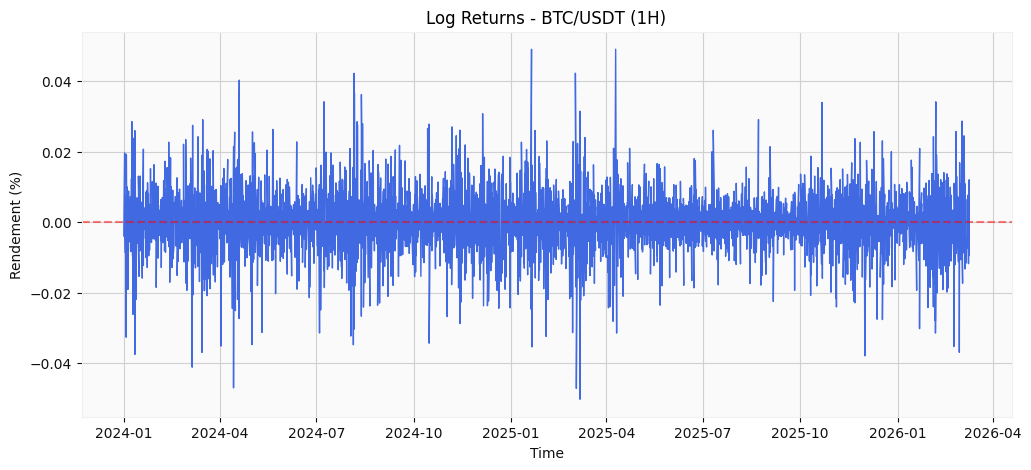

In [636]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df['close_log_return'], color='royalblue', linewidth=1)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Log Returns - BTC/USDT (1H)')
plt.ylabel('Rendement (%)')
plt.show()

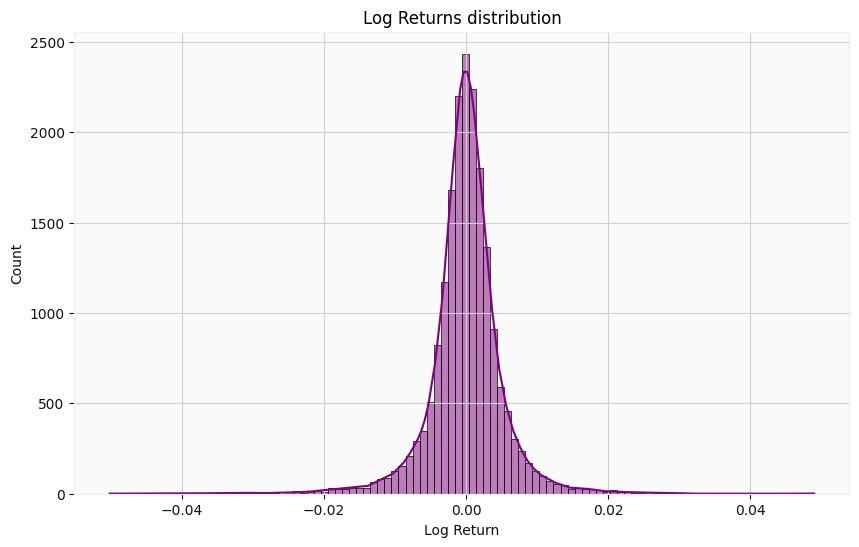

In [637]:
plt.figure(figsize=(10, 6))
sns.histplot(df['close_log_return'].dropna(), kde=True, color='purple', bins=100)
plt.title('Log Returns distribution')
plt.xlabel('Log Return')
plt.show()

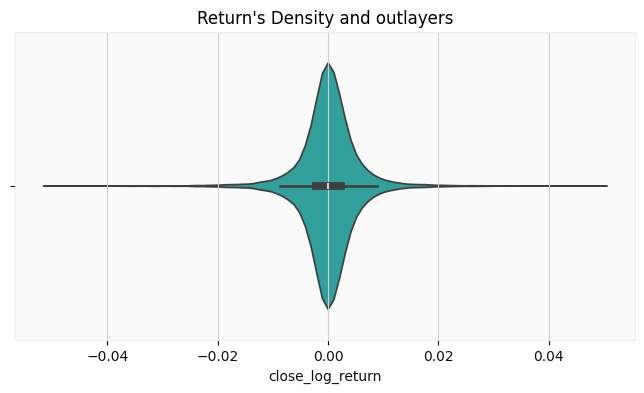

In [638]:
plt.figure(figsize=(8, 4))
sns.violinplot(x=df['close_log_return'], color='lightseagreen')
plt.title("Return's Density and outlayers")
plt.show()

In [639]:
df = feature_enginering(df).dropna()
df

,Open,High,Low,Close,Volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4,...,volume_lag_3,price_lag_6,rsi_lag_6,volume_lag_6,price_lag_12,rsi_lag_12,volume_lag_12,volatility,atr,vix_proxy
Time,,,,,,,,,,,,,,,,,,,,,
2024-01-02 19:00:00,45154.70,45243.00,44790.96,45039.49,2347.28624,-0.002554,0.004184,-0.008673,0.003822,-0.001634,...,3052.23783,-0.013113,0.184672,2253.76868,-0.009153,0.213294,3112.52478,0.006905,404.834053,0.109606
2024-01-02 20:00:00,45039.49,45180.55,44742.96,44788.28,1940.02489,-0.005593,-0.002554,0.004184,-0.008673,0.003822,...,2540.00308,-0.010395,0.000000,4553.21243,-0.021220,0.390630,3323.21707,0.005435,407.173763,0.086273
2024-01-02 21:00:00,44788.27,45119.76,44600.00,45119.74,2043.74183,0.007373,-0.005593,-0.002554,0.004184,-0.008673,...,1806.07730,-0.001440,0.000000,4301.03657,-0.012124,0.145380,2096.46195,0.005601,415.215637,0.088906
2024-01-02 22:00:00,45119.74,45297.26,44840.01,44981.73,1591.57491,-0.003063,0.007373,-0.005593,-0.002554,0.004184,...,2347.28624,-0.008292,0.099431,3052.23783,-0.013234,0.000000,2069.22249,0.004961,418.218092,0.078752
2024-01-02 23:00:00,44981.72,45049.98,44802.01,44946.91,1080.22719,-0.000774,-0.003063,0.007373,-0.005593,-0.002554,...,1940.02489,-0.000428,0.000000,2540.00308,-0.010721,0.000000,2538.49307,0.004956,406.057514,0.078680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-09 11:00:00,67608.13,67855.82,67344.45,67764.98,577.58612,0.002317,-0.005500,0.002450,0.003835,0.004272,...,1615.43129,-0.002153,1.000000,1145.71148,0.027190,0.000000,679.95244,0.006272,637.079984,0.099558
2026-03-09 12:00:00,67764.99,68348.26,67759.57,68151.93,970.32854,0.005694,0.002317,-0.005500,0.002450,0.003835,...,1225.43841,0.013153,0.710409,578.70307,0.026848,0.423993,951.35538,0.006234,633.623556,0.098957
2026-03-09 13:00:00,68151.93,69300.00,68133.93,68976.00,2460.13662,0.012019,0.005694,0.002317,-0.005500,0.002450,...,687.12244,0.021033,0.815873,1253.45589,0.041996,0.315670,2263.78882,0.006705,671.655445,0.106438


## Data Preparation

Before training the model:

1. Missing values are removed
2. Features are standardized using a scaler
3. The dataset is split into training and testing samples

A **time-series split** is used instead of random sampling to respect the chronological order of financial data.

In [640]:
y = df["close_log_return"]
dataset = df.drop(columns=["close_log_return"])

scaler = StandardScaler()

X = pd.DataFrame(
    index=df.index,
    data=scaler.fit_transform(dataset,target)
)

In [641]:
n_samples = len(X)
test_size = int(n_samples * 0.25)

tscv = TimeSeriesSplit(n_splits=2, test_size=test_size)

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

## XGBoost Model Training

The predictive model used is **XGBoost**, a gradient boosted decision tree algorithm widely used in machine learning competitions and financial modeling.

Hyperparameters are optimized using **GridSearchCV** combined with **TimeSeriesSplit** cross-validation.

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 6, 8, 10],
    'learning_rate': [0.001, 0.01, 0.05, 0.1],
    'subsample' : [0.5, 0.6, 0.7, 0.8],
    'colsample_bytree' : [0.5, 0.6, 0.7, 0.8],
    'reg_lambda' : [1.0],
    'reg_alpha' : [0.1]
}

model = xgb.XGBRFRegressor(
    eval_metric='rmse',
    random_state=42
)

grid_search = GridSearchCV(
    estimator=model, 
    param_grid=param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1600 candidates, totalling 8000 fits


## Return Prediction

Once the model is trained, predictions are generated on the test dataset.

The predicted values correspond to the **expected future log return**.

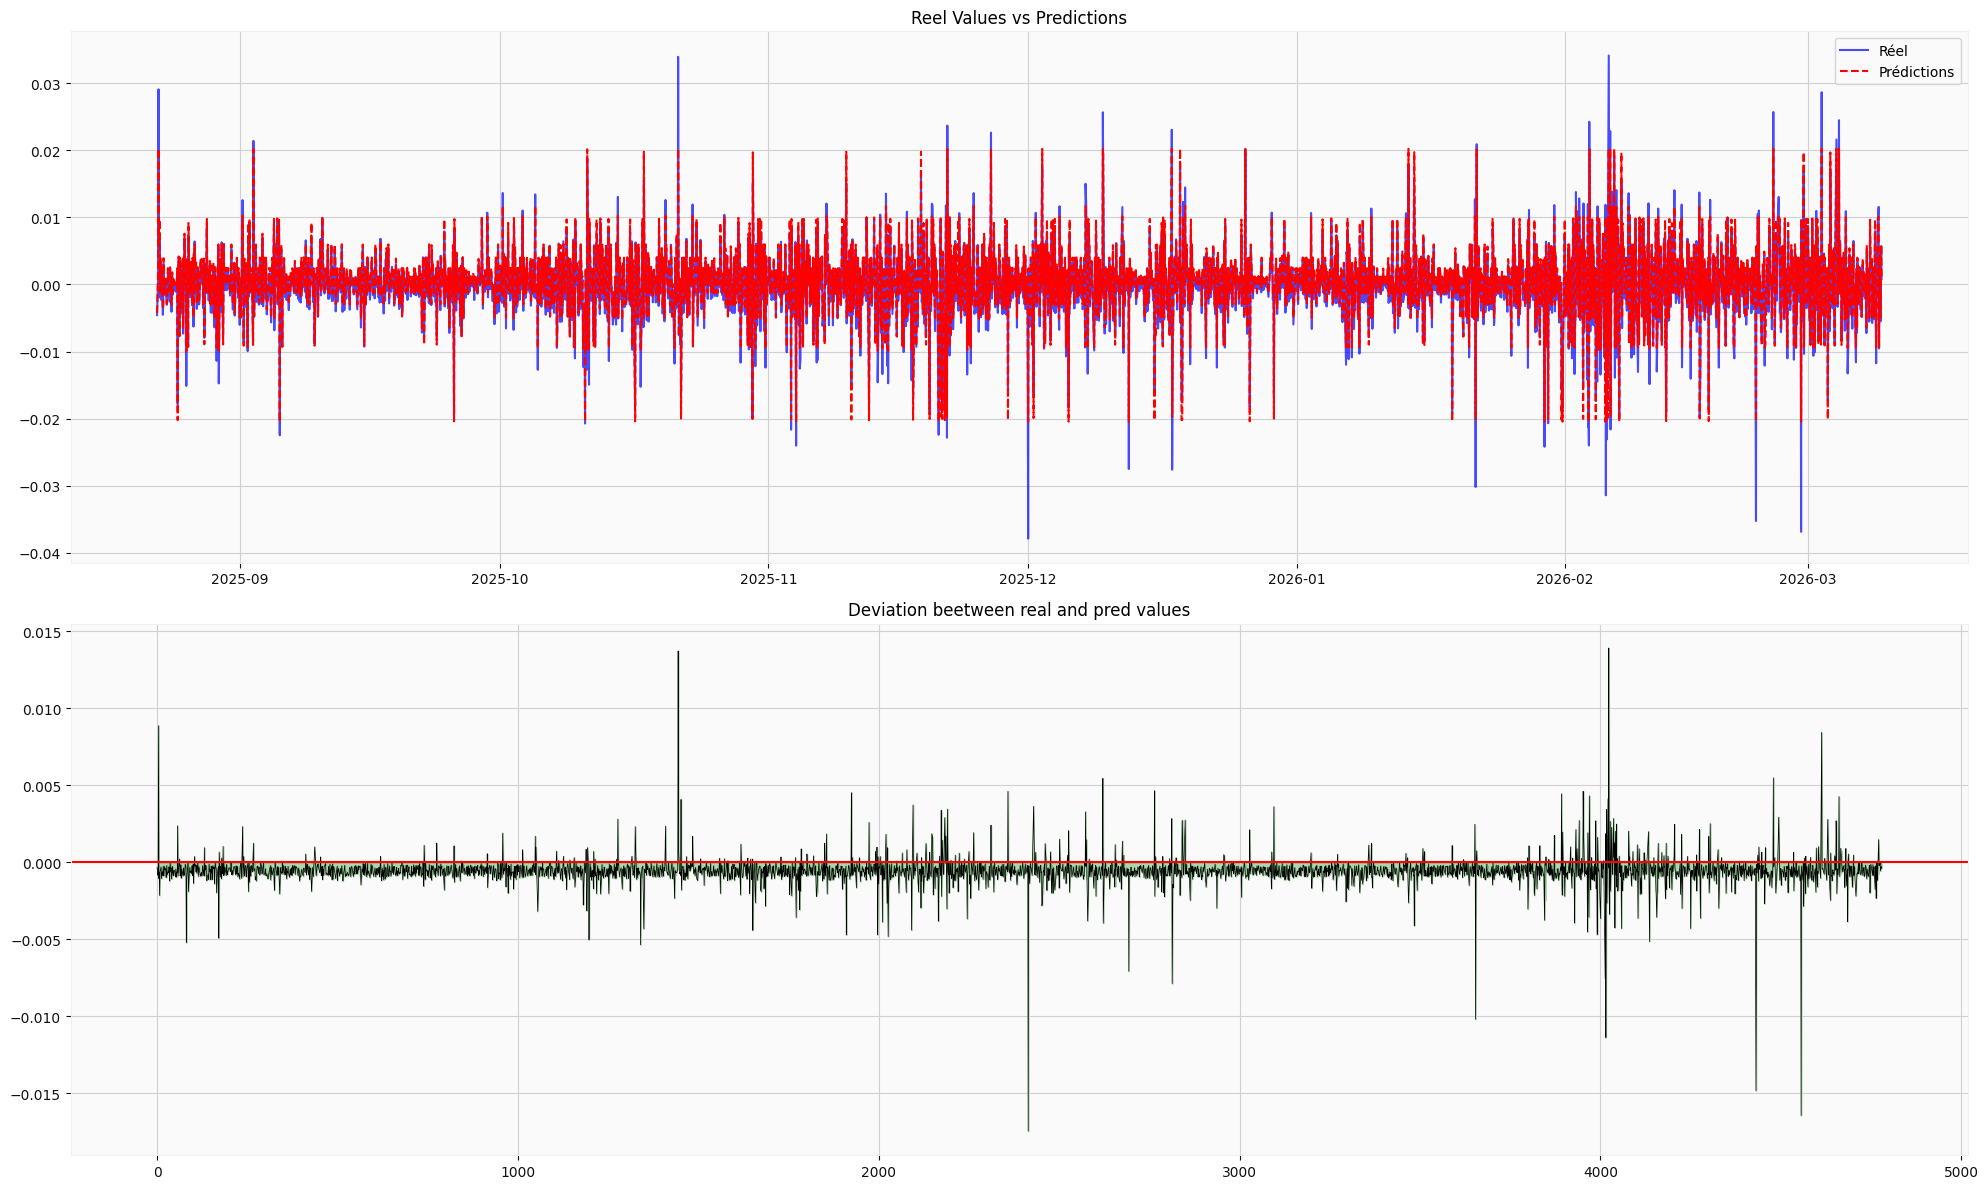

In [ ]:
predictions = pd.DataFrame(
    index=X_test.index,
    data = grid_search.predict(X_test)*10
    )

y_real = y_test.values.flatten()
y_pred = predictions.values.flatten()
residuals = y_real - y_pred
indices = range(len(residuals))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 12))

ax1.plot(y_test.index, y_real, label='Réel', color='blue', alpha=0.7)
ax1.plot(y_test.index, y_pred, label='Prédictions', color='red', linestyle='--')
ax1.set_title("Reel Values vs Predictions")
ax1.legend()

ax2.fill_between(indices, residuals, 0, color='green', alpha=0.3)
ax2.plot(indices, residuals, color='black', linewidth=0.5)
ax2.set_title("Deviation beetween real and pred values")
ax2.axhline(0, color='red', linestyle='-')

plt.tight_layout()
plt.show()

## Model Performance

Model performance is evaluated using the **Mean Squared Error (MSE)** between predicted and actual returns.

In [ ]:
mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error:", mse)

1.1626959565684426e-06

# Strategy Backtest

To evaluate the economic value of the predictions, we convert them into **trading signals**.

The strategy logic is based on a threshold:

- If predicted return > threshold → **Long position**
- If predicted return < -threshold → **Short position**
- Otherwise → **No position**

In [544]:
client = Client("", "")
dict_data = client.get_historical_klines("ETHUSDT", Client.KLINE_INTERVAL_1HOUR, "1 Jan, 2024")

df = pd.DataFrame(dict_data)

df = df.iloc[:, :6]

df.columns = ['Time', 'Open', 'High', 'Low', 'Close', 'Volume']

df['Time'] = pd.to_datetime(df['Time'], unit='ms')

df.set_index('Time', inplace=True)

df = df.apply(pd.to_numeric)

df

,Open,High,Low,Close,Volume
Time,,,,,
2024-01-01 00:00:00,2281.87,2297.18,2281.27,2295.51,10771.9183
2024-01-01 01:00:00,2295.52,2306.60,2292.90,2303.72,8413.4260
2024-01-01 02:00:00,2303.72,2304.72,2291.20,2293.02,5808.2533
2024-01-01 03:00:00,2293.03,2294.50,2271.00,2273.81,10745.7360
2024-01-01 04:00:00,2273.80,2279.86,2265.24,2279.55,9681.5762
...,...,...,...,...,...
2026-03-09 09:00:00,1996.81,2022.00,1986.77,2004.48,22759.6160
2026-03-09 10:00:00,2004.49,2007.05,1992.56,1995.41,17147.8872
2026-03-09 11:00:00,1995.41,1999.99,1980.93,1992.20,12567.4869


In [545]:
df["close_log_return"] = np.log(df["Close"]/df["Close"].shift(forecast_horizon))
df

,Open,High,Low,Close,Volume,close_log_return
Time,,,,,,
2024-01-01 00:00:00,2281.87,2297.18,2281.27,2295.51,10771.9183,NaN
2024-01-01 01:00:00,2295.52,2306.60,2292.90,2303.72,8413.4260,0.003570
2024-01-01 02:00:00,2303.72,2304.72,2291.20,2293.02,5808.2533,-0.004655
2024-01-01 03:00:00,2293.03,2294.50,2271.00,2273.81,10745.7360,-0.008413
2024-01-01 04:00:00,2273.80,2279.86,2265.24,2279.55,9681.5762,0.002521
...,...,...,...,...,...,...
2026-03-09 09:00:00,1996.81,2022.00,1986.77,2004.48,22759.6160,0.003834
2026-03-09 10:00:00,2004.49,2007.05,1992.56,1995.41,17147.8872,-0.004535
2026-03-09 11:00:00,1995.41,1999.99,1980.93,1992.20,12567.4869,-0.001610


In [546]:
target = "close_log_return"
lr = df[target]
lags = [1,2,3,4]

for lag in lags:
    df[f"{target}_lag_{lag}"] = lr.shift(forecast_horizon * lag)

df

,Open,High,Low,Close,Volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
Time,,,,,,,,,,
2024-01-01 00:00:00,2281.87,2297.18,2281.27,2295.51,10771.9183,NaN,NaN,NaN,NaN,NaN
2024-01-01 01:00:00,2295.52,2306.60,2292.90,2303.72,8413.4260,0.003570,NaN,NaN,NaN,NaN
2024-01-01 02:00:00,2303.72,2304.72,2291.20,2293.02,5808.2533,-0.004655,0.003570,NaN,NaN,NaN
2024-01-01 03:00:00,2293.03,2294.50,2271.00,2273.81,10745.7360,-0.008413,-0.004655,0.003570,NaN,NaN
2024-01-01 04:00:00,2273.80,2279.86,2265.24,2279.55,9681.5762,0.002521,-0.008413,-0.004655,0.003570,NaN
...,...,...,...,...,...,...,...,...,...,...
2026-03-09 09:00:00,1996.81,2022.00,1986.77,2004.48,22759.6160,0.003834,0.006486,-0.000554,-0.012814,0.016696
2026-03-09 10:00:00,2004.49,2007.05,1992.56,1995.41,17147.8872,-0.004535,0.003834,0.006486,-0.000554,-0.012814
2026-03-09 11:00:00,1995.41,1999.99,1980.93,1992.20,12567.4869,-0.001610,-0.004535,0.003834,0.006486,-0.000554


In [547]:
df = feature_enginering(df).dropna()
df

,Open,High,Low,Close,Volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4,...,volume_lag_3,price_lag_6,rsi_lag_6,volume_lag_6,price_lag_12,rsi_lag_12,volume_lag_12,volatility,atr,vix_proxy
Time,,,,,,,,,,,,,,,,,,,,,
2024-01-02 14:00:00,2398.01,2402.65,2354.92,2367.28,33817.2174,-0.012893,0.004661,-0.001838,-0.002881,-0.006496,...,17120.8522,-0.024402,0.793991,48568.8207,-0.006576,0.777985,13292.5147,0.006971,20.796154,0.110661
2024-01-02 15:00:00,2367.27,2371.14,2352.04,2357.48,25617.6125,-0.004148,-0.012893,0.004661,-0.001838,-0.002881,...,15110.6380,-0.023320,0.315930,21469.8389,-0.012131,0.805996,16262.0974,0.007004,20.675000,0.111187
2024-01-02 16:00:00,2357.48,2369.60,2350.19,2367.91,18916.5505,0.004414,-0.004148,-0.012893,0.004661,-0.001838,...,13619.2626,-0.012606,0.000000,19010.6342,-0.008272,0.778569,12124.3336,0.007057,20.584643,0.112023
2024-01-02 17:00:00,2367.92,2368.14,2350.95,2357.43,11178.9001,-0.004436,0.004414,-0.004148,-0.012893,0.004661,...,33817.2174,-0.014139,0.000000,17120.8522,-0.008433,0.426900,14852.3142,0.007135,20.342168,0.113258
2024-01-02 18:00:00,2357.43,2369.60,2355.54,2365.70,8386.0845,0.003502,-0.004436,0.004414,-0.004148,-0.012893,...,25617.6125,-0.008861,0.000000,15110.6380,-0.003437,0.223596,10223.5551,0.007150,19.893442,0.113502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-09 09:00:00,1996.81,2022.00,1986.77,2004.48,22759.6160,0.003834,0.006486,-0.000554,-0.012814,0.016696,...,15733.8756,0.013654,1.000000,58780.5510,0.025860,0.741422,6632.1837,0.007412,24.008199,0.117660
2026-03-09 10:00:00,2004.49,2007.05,1992.56,1995.41,17147.8872,-0.004535,0.003834,0.006486,-0.000554,-0.012814,...,13845.4139,0.009154,0.996675,10238.8798,0.026868,0.509417,58211.1708,0.007534,23.328328,0.119602
2026-03-09 11:00:00,1995.41,1999.99,1980.93,1992.20,12567.4869,-0.001610,-0.004535,0.003834,0.006486,-0.000554,...,15655.8201,-0.009151,1.000000,43830.6334,0.028445,0.388436,10128.9597,0.007543,23.023447,0.119743


In [593]:
dataset = df.drop(columns=["close_log_return"])

X = pd.DataFrame(
    data=scaler.transform(dataset), 
    index=df.index,
    columns=dataset.columns 
)

In [594]:
predictions = pd.DataFrame(
    index = X.index,
    data = grid_search.predict(X.values)*10
    )

## Signal Generation

Predictions are transformed into trading signals using a volatility-based threshold.

This avoids trading on weak predictions and reduces noise.

In [612]:
threshold = predictions[0].std() * 0.3

conditions = [
    predictions[0] < -threshold,
    predictions[0] > threshold  
]

choices = [-1, 1]

action = np.select(conditions, choices, default=0)

trading_signals = pd.DataFrame(
    index=predictions.index,
    data=action,
    columns=['Signal']
)

trading_signals

,Signal
Time,
2024-01-02 14:00:00,-1
2024-01-02 15:00:00,-1
2024-01-02 16:00:00,1
2024-01-02 17:00:00,-1
2024-01-02 18:00:00,1
...,...
2026-03-09 09:00:00,1
2026-03-09 10:00:00,-1
2026-03-09 11:00:00,0


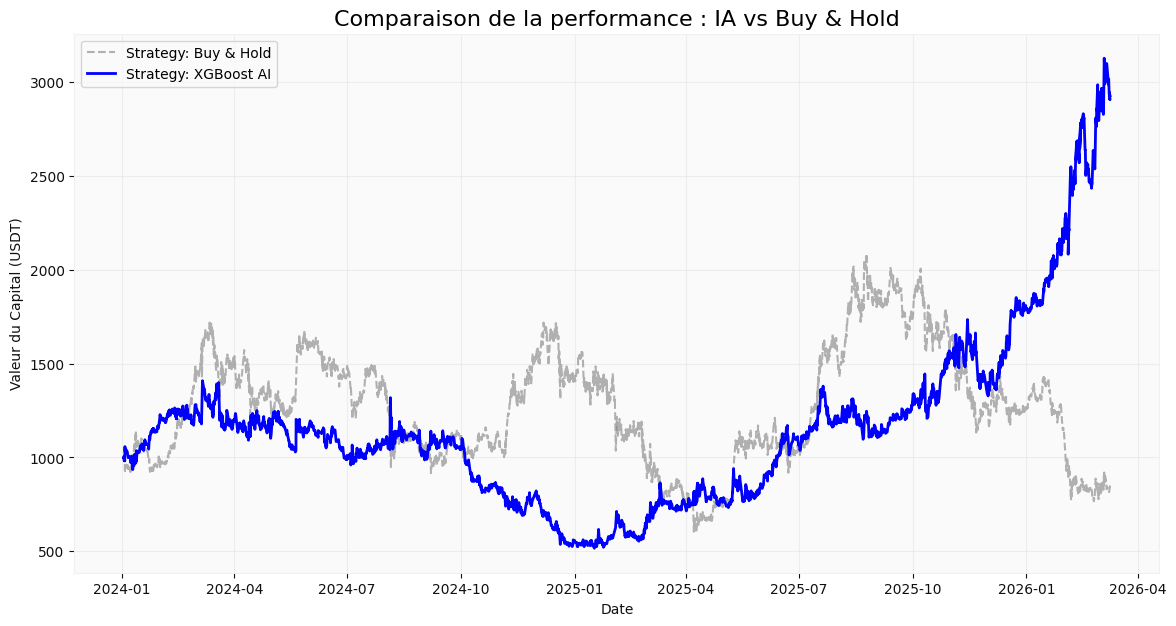

--- RÉSULTATS FINAUX ---
Capital Final Buy & Hold : 850.54 USDT
Capital Final IA         : 2925.58 USDT
Performance relative     : 243.97% par rapport au marché


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

backtest_df = df[['Close']].copy()

backtest_df['Signal'] = trading_signals.iloc[:, 0].values


initial_balance = 1000
backtest_df['Buy_Hold_Equity'] = (backtest_df['Close'] / backtest_df['Close'].iloc[0]) * initial_balance

backtest_df['Log_Return'] = np.log(backtest_df['Close'] / backtest_df['Close'].shift(1))

backtest_df['Strategy_Return'] = backtest_df['Signal'].shift(1) * backtest_df['Log_Return']

backtest_df['Strategy_Equity'] = np.exp(backtest_df['Strategy_Return'].fillna(0).cumsum()) * initial_balance

plt.figure(figsize=(14, 7))
plt.plot(backtest_df['Buy_Hold_Equity'], label='Strategy: Buy & Hold', color='gray', alpha=0.6, linestyle='--')
plt.plot(backtest_df['Strategy_Equity'], label='Strategy: XGBoost AI', color='blue', linewidth=2)

plt.title('Comparaison de la performance : IA vs Buy & Hold', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Valeur du Capital (USDT)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

final_bh = backtest_df['Buy_Hold_Equity'].iloc[-1]
final_ai = backtest_df['Strategy_Equity'].iloc[-1]

print(f"--- RÉSULTATS FINAUX ---")
print(f"Buy & Hold Strat: {final_bh:.2f} USDT")
print(f"AI Strat        : {final_ai:.2f} USDT")
print(f"Relative Performance     : {((final_ai/final_bh)-1)*100:.2f}%")

# Conclusion

This experiment explores the use of **machine learning for financial return prediction**.

Key steps included:

- feature engineering on price data
- training an XGBoost regression model
- generating trading signals
- backtesting the resulting strategy

While machine learning models can capture patterns in financial time series, markets remain highly noisy and difficult to predict. Further improvements could include:

- additional features (technical indicators, volatility metrics)
- longer training periods
- alternative models
- more robust backtesting frameworks